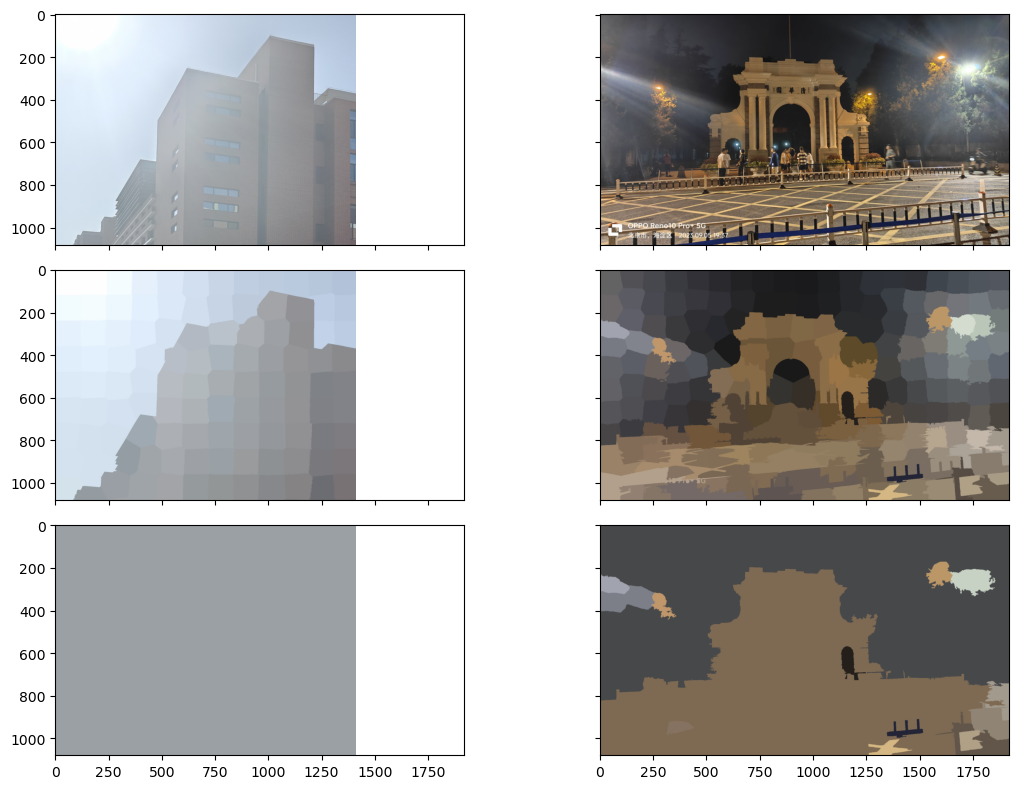

In [3]:
"""
熟悉归一化图割 使用方法
"""

from skimage import segmentation, color
from skimage import graph
from matplotlib import pyplot as plt
import cv2

# 读取图像
image1 = cv2.imread('./data/building.jpg')
img1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)

image2 = cv2.imread('./data/qinghua.jpg')
img2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)

# 提取超像素
labels1 = segmentation.slic(img1, compactness=30, n_segments=200, start_label=1)
labels11 = segmentation.slic(img2, compactness=30, n_segments=200, start_label=1)
# 利用平均颜色来输出超像素
out1 = color.label2rgb(labels1, img1, kind='avg', bg_label=0)
out11 = color.label2rgb(labels11, img2, kind='avg', bg_label=0)
# 生成RAG图
g = graph.rag_mean_color(img1, labels1, mode='similarity')
h = graph.rag_mean_color(img2, labels11, mode='similarity')
labels2 = graph.cut_normalized(labels1, g)
labels22 = graph.cut_normalized(labels11, h)

# 利用平均颜色来输出图割结果
out2 = color.label2rgb(labels2, img1, kind='avg', bg_label=0)
out22 = color.label2rgb(labels22, img2, kind='avg', bg_label=0)
fig, ax = plt.subplots(nrows=3, ncols=2, sharex=True, sharey=True, figsize=(12, 8))

ax[0, 0].imshow(img1)
ax[1, 0].imshow(out1)
ax[2, 0].imshow(out2)

ax[0, 1].imshow(img2)
ax[1, 1].imshow(out11)
ax[2, 1].imshow(out22)

plt.tight_layout()

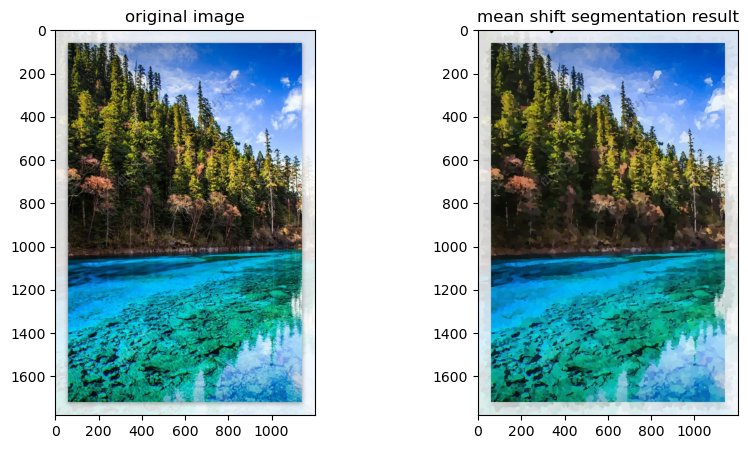

In [8]:
from skimage import io, segmentation, color
from matplotlib import pyplot as plt

# 读取图像
image = io.imread('./data/1.jpg')

# 使用均值移动法进行分割
segments = segmentation.quickshift(image, kernel_size=3, max_dist=6, ratio=0.5)

# 可视化分割结果
segmented_image = color.label2rgb(segments, image, kind='avg')

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image)
ax[0].set_title('original image')
ax[1].imshow(segmented_image)
ax[1].set_title('mean shift segmentation result')
plt.show()
